In [23]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from enum import Enum
from dataclasses import dataclass

In [27]:
class Direction(Enum):
    DIR_NONE = 0
    UP = 1
    RIGHT = 2
    DOWN = 3
    LEFT = 4
    

DIR_NONE = Direction.DIR_NONE
UP = Direction.UP
RIGHT = Direction.RIGHT
DOWN = Direction.DOWN
LEFT = Direction.LEFT


@dataclass
class TileData:
    direction: Direction
    can_take_belt: list[Direction]


In [133]:
class Tile(Enum):
    EMPTY = 0

    BELT_UP = 1
    BELT_RIGHT = 2
    BELT_DOWN = 3
    BELT_LEFT = 4

    BELT_RIGHT_UP = 5
    BELT_DOWN_RIGHT = 6
    BELT_LEFT_DOWN = 7
    BELT_UP_LEFT = 8

    BELT_UP_RIGHT = 9
    BELT_RIGHT_DOWN = 10
    BELT_DOWN_LEFT = 11
    BELT_LEFT_UP = 12

    # EMPTY = TileData(DIR_NONE, can_take_belt=[UP,RIGHT,DOWN,LEFT])
    # BELT_UP = TileData(UP, [DOWN])
    # BELT_RIGHT = TileData(RIGHT, [LEFT])
    # BELT_DOWN = TileData(DOWN, [UP])
    # BELT_LEFT = TileData(LEFT, [RIGHT])

    # BELT_RIGHT_UP = TileData(UP, [RIGHT])
    # BELT_DOWN_RIGHT = TileData(RIGHT, [DOWN])
    # BELT_LEFT_DOWN = TileData(DOWN, [LEFT])
    # BELT_UP_LEFT = TileData(LEFT, [UP])

    # BELT_UP_RIGHT = TileData(RIGHT, [UP])
    # BELT_RIGHT_DOWN = TileData(DOWN, [RIGHT])
    # BELT_DOWN_LEFT = TileData(LEFT, [DOWN])
    # BELT_LEFT_UP = TileData(UP, [LEFT])

    
    @classmethod
    def can_take_up(self) -> list:
        return [Tile.BELT_DOWN.value,
                Tile.BELT_UP_LEFT.value,
                Tile.BELT_UP_RIGHT.value]

    @classmethod
    def can_take_right(self) -> list:
        return [Tile.BELT_LEFT.value,
                Tile.BELT_RIGHT_DOWN.value,
                Tile.BELT_RIGHT_UP.value]

    @classmethod
    def can_take_down(self) -> list:
        return [Tile.BELT_UP.value,
                Tile.BELT_DOWN_LEFT.value,
                Tile.BELT_DOWN_RIGHT.value]

    @classmethod
    def can_take_left(self) -> list:
        return [Tile.BELT_RIGHT.value,
                Tile.BELT_LEFT_DOWN.value,
                Tile.BELT_LEFT_UP.value]
    
    




In [168]:
def plot_solve(solve):
    fig, ax = plt.subplots(1,solve.size(-1),figsize=(6*5, 6))
    for i, grid in enumerate(solve.permute(2,0,1)):
        ax[i].matshow(grid.detach().exp().numpy(),vmin=0,vmax=1)
        ax[i].set
        ax[i].set_title(Tile(i))
    plt.show()

In [135]:
BOX_SIZE = 5
INPUT_POS = (2,0)

In [136]:
Tile.can_take_up()

[3, 8, 9]

In [ ]:
def eval(solve,verbose=0):
    items = torch.full((BOX_SIZE, BOX_SIZE, len(Tile)), -500.0)
    items[INPUT_POS, :] = 0.0

    for _ in range(10):
        mul = items + solve

        items = torch.full((BOX_SIZE, BOX_SIZE, len(Tile)), -500.0)
        for i in range(len(Tile)):
            tile_type = Tile(i)
            
            if tile_type in [Tile.BELT_UP, Tile.BELT_LEFT_UP, Tile.BELT_RIGHT_UP]:
                idx = Tile.can_take_down()
                src = mul[1::, :, i].unsqueeze(-1).repeat(1, 1, len(idx))

                items[0:-1, :, idx] = torch.logaddexp(items[0:-1, :, idx], src)
                
            if tile_type in [Tile.BELT_RIGHT, Tile.BELT_DOWN_RIGHT, Tile.BELT_UP_RIGHT]:
                idx = Tile.can_take_left()
                src = mul[:, 0:-1, i].unsqueeze(-1).repeat(1, 1, len(idx))
                items[:, 1::, idx] = torch.logaddexp(items[:, 1::, idx], src)
                
            if tile_type in [Tile.BELT_DOWN, Tile.BELT_LEFT_DOWN, Tile.BELT_RIGHT_DOWN]:
                idx = Tile.can_take_up()
                src = mul[0:-1, :, i].unsqueeze(-1).repeat(1, 1, len(idx))
                items[1::, :, idx] = torch.logaddexp(items[1::, :, idx], src)
                
            if tile_type in [Tile.BELT_LEFT, Tile.BELT_DOWN_LEFT, Tile.BELT_UP_LEFT]:
                idx = Tile.can_take_right()
                src = mul[:, 1::, i].unsqueeze(-1).repeat(1, 1, len(idx))
                items[:, 0:-1, idx] = torch.logaddexp(items[:, 0:-1, idx], src)

        if verbose>=5:
            plt.matshow(items.detach().exp().numpy().sum(-1))
            plt.show()
    if verbose>=1:
        plt.matshow(items.detach().exp().numpy().sum(-1))
        plt.show()
        print(items.sum(),items[4,4].exp().sum())
    # print(items.sum())
    return items

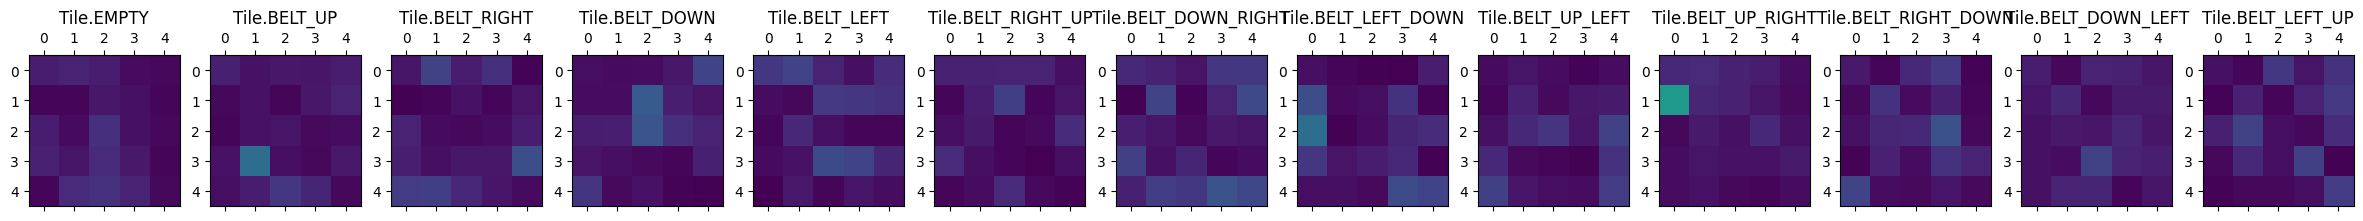

16.670019149780273
12.280220031738281
11.493898391723633
9.449355125427246
7.487836837768555
5.568626880645752
4.559664726257324
3.8755712509155273
3.9329559803009033
2.726516008377075
3.6834194660186768
3.5366761684417725
1.5480468273162842
0.9083669185638428
1.3489940166473389
3.115543842315674
2.835390090942383
0.5259963274002075
-0.4085381031036377
0.4809988737106323
0.4696049690246582
-0.3395296335220337
-0.5566955804824829
-0.6750766038894653
-0.7648203372955322
-0.8787219524383545
-0.7979844808578491
-0.9975718855857849
-1.010179042816162
-1.0682504177093506
-1.0618641376495361
-0.5024181604385376
-0.6283459067344666
-0.941170334815979
-1.050011157989502
-1.0402098894119263
-1.0713659524917603
-1.0679101943969727
-1.0798752307891846
-1.0916104316711426
-1.0894458293914795
-1.0710698366165161
-1.0891659259796143
-1.0832467079162598
-1.08629310131073
-1.040885090827942
-1.0751466751098633
-1.0669101476669312
-1.07340407371521
-1.0046859979629517
-1.0306031703948975
-1.048693895339

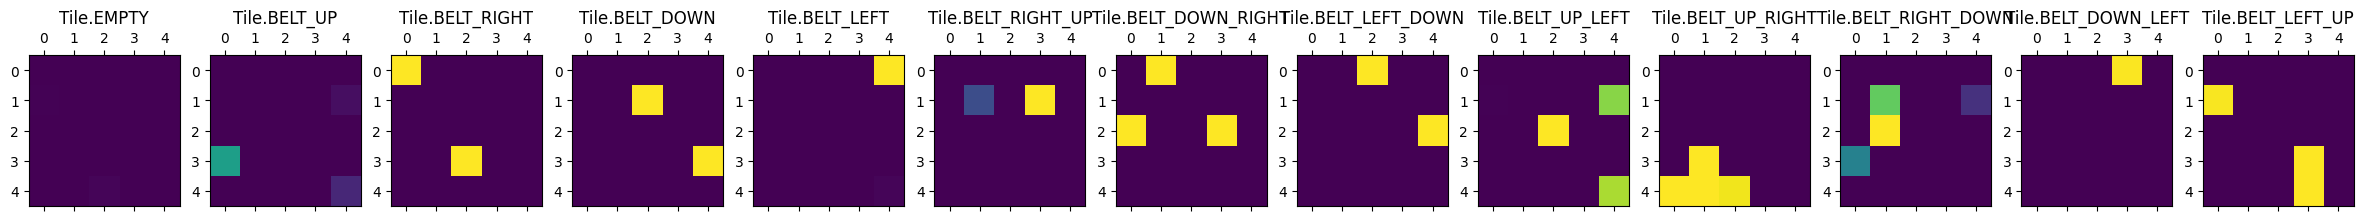

-1.09745192527771
-1.0977059602737427
-1.0982428789138794
-1.098035454750061
-1.0981446504592896
-1.0964972972869873
-1.098209261894226
-1.09836745262146
-1.0963536500930786
-1.0974396467208862
-1.09702467918396
-1.0979936122894287
-1.098244547843933
-1.0963642597198486
-1.0926433801651
-1.0755945444107056
-1.079013705253601
-1.0891412496566772
-1.0848833322525024
-0.954624593257904
-0.9141507744789124
-0.8942259550094604
-1.001363754272461
-0.4980320334434509
-0.9797906279563904
-1.0876550674438477
-1.088511347770691
-1.0827468633651733
-1.0961307287216187
-1.0877705812454224
-1.0932557582855225
-1.0946919918060303
-1.0968856811523438
-1.0844179391860962
-1.0966242551803589
-1.0962923765182495
-1.096412181854248
-1.0984574556350708
-1.09831964969635
-1.097260594367981
-1.0955790281295776
-1.0926904678344727
-1.0780078172683716
-1.0752522945404053
-1.079210877418518
-1.0792399644851685
-1.0967442989349365
-1.0976642370224
-1.09458327293396
-1.0961054563522339
-1.0959633588790894
-1.098

KeyboardInterrupt: 

In [170]:
logits = 0.01 * torch.randn(BOX_SIZE,BOX_SIZE,len(Tile))

logits.requires_grad_()
# solve = smax(solve)

MAX_ITER = 500

opt = torch.optim.Adam([logits], lr=0.1)
sch = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=100, T_mult=2)

for iter in range(MAX_ITER):
    with torch.no_grad():
        logits += 0.2 * torch.randn_like(logits)
    solve = torch.log_softmax(logits*5, dim=-1)

    if iter%250==0:
        plot_solve(solve)

    
    loss = -torch.logsumexp(eval(solve)[4, 4, :], dim=-1)
    
    # loss += solve[:,:,1::].mean() * 0.01
    # loss += 3* ((1-solve.sum(dim=-1))**2).mean()
    print(loss.item())
    # print(loss.grad_fn)
    
    # if loss.item()<0.05:
    #     break

    loss.backward()
    # print(logits.grad)
    opt.step()
    opt.zero_grad()
    # sch.step()


In [167]:
eval(solve,verbose=10)

AttributeError: 'numpy.ndarray' object has no attribute 'exp'